In [40]:
pip install dilithium-py

Note: you may need to restart the kernel to use updated packages.


In [68]:
pip install cryptography

Note: you may need to restart the kernel to use updated packages.


In [213]:
pip install qiskit

Note: you may need to restart the kernel to use updated packages.


In [216]:
pip install qiskit-aer

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 5.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.6 MB 5.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 6.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 6.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 7.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [220]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from dilithium_py.ml_dsa import ML_DSA_44 # NIST Level 2 (comparable to P-256)
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate

# **1 Introduction**

**Module-Lattice-Based Digital Signature Algorithm (ML-DSA)** is a digital signature algorithm approved and specify by NIST in FIPS 204. It is based on the Module Learning With Errors problem (MLWE) and is believed to be secure, even against quantum computers. In particular, ML-DSA is believed to be strongly unforgeable (SUF-CMA), which implies that the scheme can be used to detect unauthorized modifications to data (protect the integrity of the message) and to authenticate the identity of the signing authority (one bound to the possession of the private-key). In addition, a signature generated by this scheme can be used as evidence in demonstrating to a third party that the signature was, in fact, generated by the claimed signing authority. This property is known as non-repudiation since the signing authority cannot easily repudiate the signature at a later time.


ML-DSA is specifically designed to phase out and replace the current industry standard algorithms. The problem with current digital signature algorithms, like RSA or ECDSA, is that they rely on mathematical problems (like factoring large numbers or discrete logarithms) that quantum computers are exceptionally good at solving. They use Shor’s Algorithm and are capable to solve these algorithms within an hours or days instead of centuries compared to the regular computers. 

A promising replacement is the lattice-based cryptography. Instead of relying on number factoring or curve math, it is based on geometric shapes made up from points in space organized in grids, called lattices. The tricky problem with the lattices is finding the shortest or closest vector in one of these lattices.
ML-DSA uses specific type of lattice structure called module lattices.


    

## ML-DSA security Levels

ML-DSA is standardized with three possible parameter sets, each of which corresponds to a different security strength.
 - ML-DSA 87
 - ML-DSA 65
 - ML-DSA 44
    
There is a tradeof between security strength and the performance in the different variants.
The most secure variant is ML-DSA 87, but it is also the slowest one. The least security strength is for ML-DSA 44, but it is the fastest one.
    

# **2. Core Mathematical Concepts**

The mathematics of ML-DSA, is built on the **Fiat-Shamir with Aborts** framework. It relies on the hardness of the **Module Learning With Errors (M-LWE)** and **Module Short Integer Solution (M-SIS)** problems.

## **2.1 Polynomial Ring ($\mathbb{R}_q$)** 

ML-DSA works in a ring of polynomials: $$\mathbb{R}_q = \mathbb{Z}_q[X]/X^{256} + 1$$

**Structure of $\mathbb{R}_q$:**

$q$ - is a prime number. For ML-DSA $q = 8 380 417$.

$\mathbb{Z}_q$ - coefficients ring. All coefficients are modulo $q$.

$\bullet$ **Elements:** Polynomials of the form $f(x) = a_0 + a_1x + a_2x^2 + \cdot\cdot\cdot + a_{255}x^{255}$.

$\bullet$ **Coefficients:** The coefficients $a_i$ are integers in $\mathbb{Z}_q$, meaning they are taken modulo $q$ (e.g. $q = 8 380 417$, for ML-DSA).

$\bullet$ **Reduction Rule:** Polynomial multiplication is performed modulo $X^{n} + 1$. For ML-DSA $n = 256$. This implies the relationship $X^{256}\equiv -1 \; (mod\ X^{256} + 1)$.

$\bullet$ **Representation:** As an implementer, this is effectively an array of 256 coefficients, each a uint16 in C. 

This means adding and multiplying polynomials of degree 255, and every coefficient is kept "in check" by the prime $q$.





**Example Polynomials Addition and Multiplication:**

Let $q = 8 380 417$ (the modulus used in ML-DSA) and consider two elements $A(x), B(x) \in \mathbb{R}_q$.
1. **Addition:**

Adding two polynomials is just component-wise addition modulo $q$.

$$A(X) = 2x^2 + 5$$

$$B(X) = 3x^2 + 1$$

$$A(x) + B(x) = (2 + 3)x^2 + (5 + 1) = 5x^2 + 6 \ (mod\ 8 380 417)$$

2. **Multiplication (Reduction Rule):**
Multiplication is polynomial multiplication followed by reducing the degree using $X^{256} = -1$.

Consider an example, $\mathbb{Z}[X]/(X^4 + 1)$, to show the reduction:
Let:
$$A(x) = 3x^2 + 5x + 2$$
$$B(x) = 4x^3 + x + 7$$

Standard multiplication:
$$(3x^2 + 5x + 2)\cdot(4x^3 + x + 7) =$$
$$= 14 + 2x + 8x^3 + 35x +5x^2 + 20x^4 + 21x^2 + 3x^3 + 12x^5 =$$ 
$$12x^5 + 20x^4 + 11x^3 + 26x^2 + 37x + 14$$

Reduce modulo $(X^4 + 1)$:
$$X^4 \equiv -1$$

$$X^5 = X\cdot X^4 \equiv -x$$

Substitute:
$$12(-x) + 20(-1) + 11x^3 + 26x^2 + 37x + 14 =$$
$$11x^3 + 26x^2 + (37 -12)x + (14 -20) =$$
$$11x^3 + 26x^2 + 25x -6$$

In the case of $\mathbb{R}_q = \mathbb{Z}_q[X]/X^{256} + 1$, if a multiplication results in a term $X^{256}$, it becomes $-1$. If it results in $X^{257}$, it becomes $-X$.


## **2.2 Number Theoretic Transform (NTT):**

This is a specialized version of the **Fast Fourier Transform (FFT)** used to multiply polynomials in $O(n\ log\ n)$ time instead of $O(n^2)$.

Instead of storing coefficients, the polynomial is evaluated at special points. These points are the so called root of unity ($\omega^{256} = 1$). 
In the NTT domain, multiplication is just multiplying the corresponding evaluations. This is the step that makes it so fast.

The NTT is an example of a basis vectors change. The basis for the polynomial ring is changed (from the standard basis ${1,x,x^2, ...}$ to a point-evaluation basis). This allows the matrix-vector multiplication to be performed much faster.

For a sequence of coefficients $a = (a_0, a_1, ..., a_{n-1})$ in a finite field $\mathbb{Z}_q$, the **NTT** $\hat{a}$ is defined as:
$$\hat{a}_j = \sum_{i=0}^{n-1} a_i\cdot\omega^{ij}\ (mod \ q), \quad j = 0, 1, ..., n-1 $$

Where 

$\omega$ is a primitive $n$-th root of unity modulo $q$. This means  $\omega^{n} \equiv 1\ (mod\ q)$ and $\omega^k \not\equiv 1$ for any $k < n$.

$n$ is a divisor of $q - 1$.

**The Inverse Transform (iNTT)** - to map values back to the coefficient domain:
$$ a_i = n^{-1}\sum_{j=0}^{n-1}\hat{a}_j\cdot\omega^{-ij}\ (mod \ q), \quad i = 0, 1, ..., n-1$$

Here, $n{-1}$ is the modular multiplicative inverse of $n$ modulo $q$.


**Example NTT:** To illustrate the Number Theoretic Transform (NTT), let's multiply two simple polynomials using a small finite field.

**Modulus ($q$):** $17$ (a prime).

**Length ($n$):** 4 (since 4 divides 17-1 = 16).

**Primitive $n$-th root of unity ($\omega$):** 4 (because $4^4 \equiv 1\ (mod\ 17)$ and there is no smaller power that is 1).

**Polynomials:**

$$A(x) = 3x^2 + x + 2$$
and
$$B(x) = 2x^2 + 1$$

Vector A: $[2,1,3,0]$ (coefficients of $1, x, x^2, x^3$)

Vector B: $[1, 0, 2, 0]$


In [242]:
def ntt(a, n, q, omega):
    """Computes the Forward NTT of a sequence a modulo q."""
    A = [0] * n
    for j in range(n):
        val = 0
        for i in range(n):
            # Standard NTT formula: sum(a[i] * omega^(i*j) mod q)
            val = (val + a[i] * pow(omega, i * j, q)) % q
        A[j] = val
    return A

In [243]:
def intt(A, n, q, omega):
    """Computes the Inverse NTT of a sequence A modulo q."""
    # Compute modular inverses needed for INTT
    omega_inv = pow(omega, q - 2, q) # Modular inverse of root
    n_inv = pow(n, q - 2, q)         # Modular inverse of length
    
    # Reuse the NTT logic with the inverse root
    raw_a = ntt(A, n, q, omega_inv)
    
    # Apply the 1/n scaling factor
    return [(x * n_inv) % q for x in raw_a]

In [258]:
# --- Example Usage ---
# 1. Setup Parameters (q must be prime and n must divide q-1)
n = 8
q = 17  # 17 is prime; 17-1 = 16, which is divisible by 8
# A primitive 8th root of unity modulo 17 is 9 (since 9^8 % 17 == 1)
omega = 9 

# 2. Define a polynomial (padded to length n)

poly = [1, 3, 2, 0, 0, 0, 0, 0 ]

# 3. Transform and Recover
transformed = ntt(poly, n, q, omega)
recovered = intt(transformed, n, q, omega)

print(f"Original:  {poly}")
print(f"NTT:       {transformed}")
print(f"Recovered: {recovered}")

Original:  [1, 3, 2, 0, 0, 0, 0, 0]
NTT:       [6, 3, 4, 3, 0, 0, 11, 15]
Recovered: [1, 3, 2, 0, 0, 0, 0, 0]


In [259]:
def ntt_multiply(poly_a, poly_b, n, q, omega):
    """Full polynomial multiplication using NTT and iNTT."""
    # Ensure inputs are padded to length n
    a_padded = poly_a + [0] * (n - len(poly_a))
    b_padded = poly_b + [0] * (n - len(poly_b))
    
    # 1. Transform
    hat_a = ntt(a_padded, n, q, omega)
    hat_b = ntt(b_padded, n, q, omega)
    
    # 2. Pointwise Multiplication
    hat_c = [(hat_a[i] * hat_b[i]) % q for i in range(n)]
    
    # 3. Inverse Transform back to coefficients
    return intt(hat_c, n, q, omega)

In [261]:
# 1. Define two polynomials (coefficients of 1, x, x^2...)
poly_a = [1, 3, 2]
poly_b = [5, 1]

# 2. Set NTT parameters
n = 8
q = 17
omega = 9 

# 3. Call the function
result = ntt_multiply(poly_a, poly_b, n, q, omega)

# 4. Print result
print(f"Polynomial Result Coefficients: {result}")
# Expected: [5, 16, 13, 2] -> 5 + 16x + 13x^2 + 2x^3

Polynomial Result Coefficients: [5, 16, 13, 2, 0, 0, 0, 0]


## **2.3 Rejection Sampling:**

Rejection Sampling is a critical security mechanism that restarts the signing process if the output might leak information about the private key. Without this step, an attacker could collect many signatures and use statistical analysis to reconstruct the secret key's unique "shape". By only keeping signatures that fit a uniform, secret-independent distribution, ML-DSA remains secure even against quantum computers.
  
A candidate signature is calculated as:
$$z = y + c\cdot s$$
Where:

$y$: A random masking vector.

$c$: A small, sparse challenge (from a hash function).

$s$: The secret key (small coefficients).
  
The signer checks:
$$\parallel{z}\parallel_\infty \  \gamma_1 - \beta$$
Where:

$\gamma_1$: The "masking" range (the size of our random buffer).

$\beta$: The maximum possible value of $c\cdot s$.

If $\parallel{z}\parallel_\infty$ is small enough, then for any possible secret $s$, there exists a valid $y$ that could have produced that $z$.

ML-DSA only accepts $z$ if it is in the "safe zone," the probability distribution of $z$ becomes perfectly uniform over the range $[-(\gamma_1 - \beta), (\gamma_1 - \beta)]$.

Since the distribution is now uniform and independent of $s$, the signature leaks zero information about the key.

## The Exact Sequence of Steps
1. **Key Generation**
   In ML-DSA, key generation creates a public/private key pair based on the Module Learning with Errors (MLWE) problem. Unlike RSA, which uses prime numbers, ML-DSA uses "small" polynomials in a module lattice to ensure security against quantum computers.
   The process involves creating a secret relationship that is easy to compute but extremely hard for an attacker to reverse.

    1.1 **Generate Public Matrix $A$:** A large public $k \times{l}$ matrix of polynomials is generated from a random 256-bit seed. This matrix acts as the "base" of the lattice.
   
    1.2 **Sample Secrets:** Two "short" vectors (lists of polynomials with very small coefficients) $s_1$ and $s_2$, are chosen.

   $s_1$ - secret vector (length $l$).

    $s_2$ - error vector (length $k$).
   
    1.3 **Compute Public Key:** The vector $t = As_1 + s_2$ is calculated. The public key is $(A,t)$.

   $-$ **Purpose:** This creates the **Module-LWE** (Learning with errors) problem. An attacker sees $A$ and $t$, but finding $s_1$ is computationally "hard" because of the added noise $s_2$ and the lattice structure.

   The matrix $A$ (public) and the secret vectors $s_1,s_2$ (private) define a lattice. The public key $t = As_1 + s_2$ is essentially a set of points that are "near" the lattice defined by $A$. Adding the error vector $s_2$ hides the exact lattice points.


    $-$ **Power2Round: Compressing the Public Key ($t$)**

Instead of sending the full values of $t$, ML-DSA "splits" $t$ into two parts:

   $t_1$ **(The High-Order Bits):** This is the compressed version sent in the public key. It is calculated as $t_1 = (t - t_0)/2^d$.

   $t_0$ **(The Low-Order Bits):** This is the "remainder" or error created by the compression, which is kept as part of the private key.

ML-DSA uses a power of two, $d = 13$. For each coefficient $r$ in $t$: $$r =r_1 \cdot 2^d + r_0$$

$t_1$ is essentially $r \gg d$ (shifting bits right).

$t_0$ is $r (mod\ a^d)$ (the dropped bits).

This a perfromance optimization:
By only making $t_1$ public, the public key size is reduced by about 40-50%. During verification, the verifier uses a hint included in the signature and "reconstructs" the necessary parts of $t$.

 Since the security of ML-DSA relies on the difficulty of finding "small" secrets ($s_1, s_2$) given the "large" public result, removing the last few bits of that result doesn't make the attacker's job easier; it actually makes it slightly harder because they have less precise information to work with.

   
2. **Signing (The Fiat-Shamir with Aborts Sequence)** To sign a message $M$, it uses a "commitment" and a "challenge" to prove the signer knows the secret without actually revealing it.

    2.1 **Commitment ($w$):** The signer picks a random Masking Vector($y$). These are "medium-sized" polynomials—larger than the secrets, but not so large that they overflow the system.

   Compute $w = Ay$. Like the public key, $w$ is compressed to its high-order bits, called $w_1$.

    2.2 **Challenge ($c$):** Hash the message $M$ and $w_1$ to produce a challenge $c$. This ensures the signature is tied to a fresh random value for every message.

    $c$ is a polynomial with predefined number of coefficients depending on the algorithm variant (60 coefficients in the case of ML-DSA 87) as $\pm1$ and the rest $0$.

    2.3 **Potential Signature ($z$):** Compute $z = y + cs_1$. It does not actually contain $w$. Instead, it contains the challenge $c$, which is a HASH of $w_1$ (High Bits).

    2.4 **The "Abort" Check:** This is the most important step. If $z$ or the "low bits" of the result are too large, they could leak the secret $s_1$. If they exceed a specific bound, the algorithm **restarts** from Step 2.1.
  
    2.5 **Output:** If it passes, the signature is $(z, c, h)$, where $h$ is a small "hint" - small bitmask that tells the verifier which coefficients in the final calculation need to "carry over" or round up.
  
5. **Verification**
The verifier checks if the mathematical identity holds without knowing $s_1$.

    3.1 **Unpack**: The verifier splits the signature into the challenge hash ($c$), the response ($z$), and the hint ($h$).

    3.2 **Range Check**: The verifier checks if the coefficients in the vector $z$ are within the allowed "small" bounds. If $z$ is too large, the signature is rejected immediately (this prevents certain attacks).

    3.3 **Reconstruct Commitment ($w'$):** The verifier takes the signature $z$ and the public key $(A,t_1)$ and computes $w{\ '} = Az -ct_1 \cdot 2^d$.

   _(Note: $2^d$ is used to "shift" the compressed public key back to its original scale)._

   $-$ _Mathematical Proof:_ $A(y + cs_1) - c(As_1 + s_2) = Ay - cs_2$.

    3.4 **Apply the Hint ($h$):** The verifier uses the hint $h$ to adjust $w'$. This "fixes" any rounding errors caused by the bits that were dropped during public key compression. This results in the high-order bits of the reconstructed commitment, called $w'_1$.

    3.5 **Final Hash:** The verifier hashes the message and the reconstructed $w'_1$.

    3.5 **Final Comparison:** The verifier checks if the hash of the reconstructed $w'_1$  matches the challenge $c$ provided in the signature. If the hashes match, the signature is valid.

   **Purpose:** Because $z = y + cs_1$ and $t = As_1 + s_2$, the term $A(cs_1)$ cancels out, leaving the verifier with a value derived from the original $Ay$. If the hash of this result matches the challenge $c$, the signature is **Valid**.

Example of key generation, signing and verification using ML-DSA 44:

In [110]:
# Example of signing
pk, sk = ML_DSA_44.keygen()
#print("pk", pk)
#print("sk", sk)
msg = b"My first usage of ML-DSA!"
print(msg)
sig = ML_DSA_44.sign(sk, msg)

print("\nTest Signature Verification:\n")
print("\n* Test with valid signature.\n")
result = ML_DSA_44.verify(pk, msg, sig)
print("Verification result:", result)
print()

print("\n* Test with invalid message.\n")
# Verification will fail with the wrong msg or pk
result = ML_DSA_44.verify(pk, b"", sig)
print("Verification result:", result)
print()
print("\n* Test with invalid public key.\n")
pk_new, sk_new = ML_DSA_44.keygen()
#print("pk_new", pk_new)
#print("sk_new", sk_new)
result = ML_DSA_44.verify(pk_new, msg, sig)
print("Verification result:", result)

b'My first usage of ML-DSA!'

Test Signature Verification:


* Test with valid signature.

Verification result: True


* Test with invalid message.

Verification result: False


* Test with invalid public key.

Verification result: False


# **3 Classical vs. post-quantum cryptography**

## ML-DSA vs. ECDSA

The transition from classical to Post-Quantum Cryptography (PQC) introduces significant trade-offs, particularly regarding data size and mathematical complexity. Below is a comparison between ML-DSA (Module-Lattice-Based Digital Signature Algorithm) and the classical ECDSA (Elliptic Curve Digital Signature Algorithm). 


|Feature|	ECDSA (Classical)|	ML-DSA (Post-Quantum)|
| :--- | :---: | :---: |
|Mathematical Basis	|Elliptic Curve Discrete Logarithm	|Lattice-based (Module-LWE)
|Standardization	|FIPS 186-5	|FIPS 204 (NIST PQC Standard)|
|Quantum Resistance	|❌ Vulnerable to Shor’s Algorithm	|✅ Resistant to Quantum Attacks|
|Public Key Size	|~64 Bytes (Very Small)	|~1,312 Bytes (Large)|
|Signature Size	|~64 Bytes (Very Small)	|~2,420 Bytes (Large)|
|Signing Speed	|Fast	|Fast (Uses Rejection Sampling)|
|Verification Speed	|Moderate	|Extremely Fast|
|Memory Usage	|Very Low	|Higher (Kilobytes)

Security Correspondence: ML-DSA vs. ECDSA
|NIST Security Level 	|Classical Security (bits)	|Traditional ECDSA Curve |ML-DSA Variant (Lattice)|
| :--- | :---: | :---: | :---: |
|Level 2	|128	|P-256 |ML-DSA-44	
|Level 3	|192		|P-384 |ML-DSA-65
|Level 5	|256		|P-521 |ML-DSA-87

Comparison: ECDSA vs. ML-DSA Data Sizes
|Algorithm	|NIST Level	|Public Key (Bytes)	|Private Key (Bytes)	|Signature (Bytes)
| :--- | :---: | :---: |:---: |:---: |
|ECDSA P-256	|2	|64	|32	|64|
|ML-DSA-44	|2	|1,312	|2,560	|2,420|
|ECDSA P-384	|3	|96	|48	|96|
|ML-DSA-65	|3	|1,952	|4,032	|3,309|
|ECDSA P-521	|5	|132	|66	|132|
|ML-DSA-87	|5	|2,592	|4,896	|4,627|


In the following graphics the performance of both algorithms can be seen. 

In [119]:
def compare_ecdsa_vs_mldsa(plain_text_message):
    results = {"ECDSA (P-256)": {}, "ML-DSA-44": {}}
    plain_text_message = b"Performance comparison of ECDSA vs ML-DSA!zesjnxkjrcxhfjxsehrxkanwzmwjkyrjecnghj3487587db46bq98347bxyiraeemz0;293opm8uzxoirkxj0;92o139[z1-m80r9oirysxhqni, ajkfed"

    # --- ECDSA ---
    # ECDSA Key Gen & Size
    sk_ec = ec.generate_private_key(ec.SECP256R1())
    pk_ec = sk_ec.public_key()
    results["ECDSA (P-256)"]["pk_size"] = 64
    results["ECDSA (P-256)"]["sk_size"] = 32
    
    # ECDSA Signing
    start = time.perf_counter()
    sig_ec = sk_ec.sign(plain_text_message, ec.ECDSA(hashes.SHA256()))
    results["ECDSA (P-256)"]["sign_time"] = (time.perf_counter() - start) * 1000
    results["ECDSA (P-256)"]["sig_size"] = len(sig_ec)

    # ECDSA Verification
    start = time.perf_counter()
    pk_ec.verify(sig_ec, plain_text_message, ec.ECDSA(hashes.SHA256()))
    results["ECDSA (P-256)"]["verify_time"] = (time.perf_counter() - start) * 1000

    # --- ML-DSA ---
    # ML-DSA Key Gen & Size
    pk_ml, sk_ml = ML_DSA_44.keygen()
    results["ML-DSA-44"]["pk_size"] = len(pk_ml)
    results["ML-DSA-44"]["sk_size"] = len(sk_ml)    
    
    # ML-DSA Signing
    start = time.perf_counter()
    sig_ml = ML_DSA_44.sign(sk_ml, plain_text_message)
    results["ML-DSA-44"]["sign_time"] = (time.perf_counter() - start) * 1000
    results["ML-DSA-44"]["sig_size"] = len(sig_ml)
    # ML-DSA Verification
    start = time.perf_counter()
    ML_DSA_44.verify(pk_ml, message, sig_ml)
    results["ML-DSA-44"]["verify_time"] = (time.perf_counter() - start) * 1000

    return results

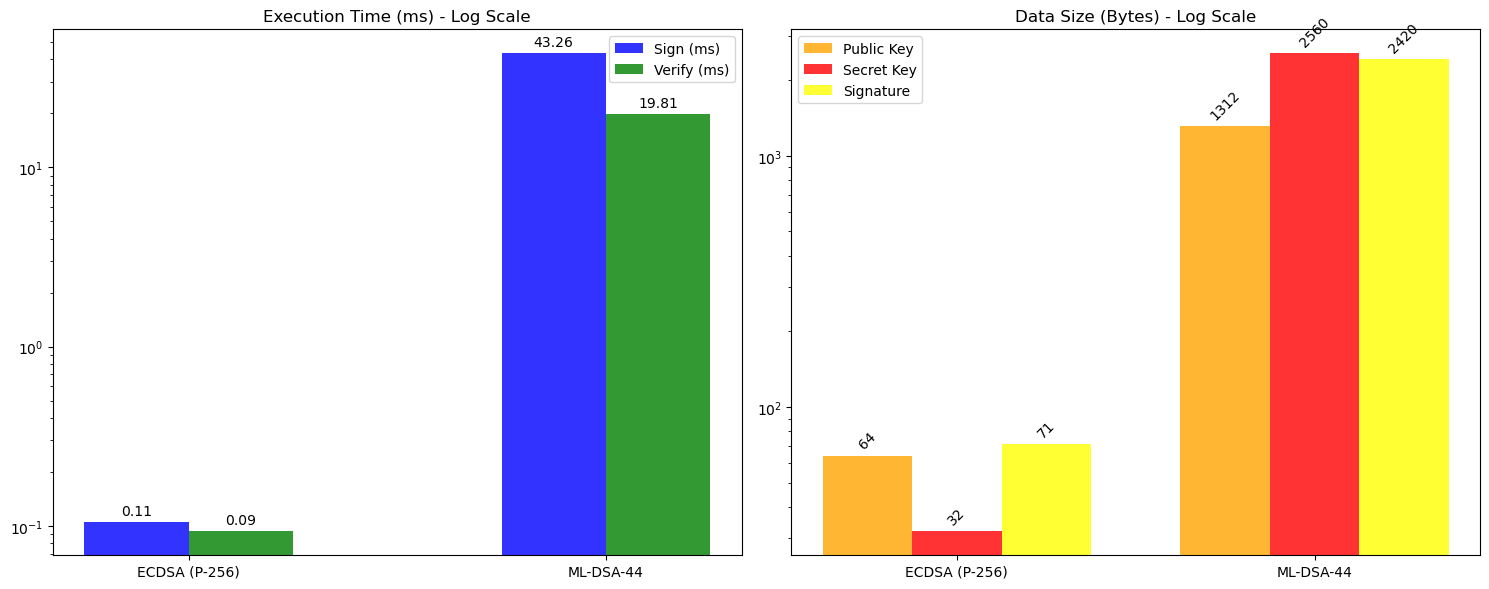

In [141]:
# Data Setup
labels = list(data.keys())
x = np.arange(len(labels))  # label locations
width = 0.25  # width of the bars

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: TIMING (Side-by-Side) ---
sign_times = [data[l]["sign_time"] for l in labels]
verify_times = [data[l]["verify_time"] for l in labels]

rects1 = axs[0].bar(x - width/2, sign_times, width, label='Sign (ms)', color='blue', alpha=0.8)
rects2 = axs[0].bar(x + width/2, verify_times, width, label='Verify (ms)', color='green', alpha=0.8)

axs[0].set_title("Execution Time (ms) - Log Scale")
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].set_yscale('log') # Essential for seeing ECDSA vs ML-DSA
axs[0].legend()
axs[0].bar_label(rects1, padding=3, fmt='%.2f')
axs[0].bar_label(rects2, padding=3, fmt='%.2f')

# --- PLOT 2: SIZES (Side-by-Side) ---
pk_sizes = [data[l]["pk_size"] for l in labels]
sk_sizes = [data[l]["sk_size"] for l in labels]
sig_sizes = [data[l]["sig_size"] for l in labels]

rects3 = axs[1].bar(x - width, pk_sizes, width, label='Public Key', color='orange', alpha=0.8)
rects4 = axs[1].bar(x, sk_sizes, width, label='Secret Key', color='red', alpha=0.8)
rects5 = axs[1].bar(x + width, sig_sizes, width, label='Signature', color='yellow', alpha=0.8)

axs[1].set_title("Data Size (Bytes) - Log Scale")
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels)
axs[1].set_yscale('log') # Crucial: ML-DSA is massive compared to ECDSA
axs[1].legend(loc='upper left')

# Add labels to the size bars
axs[1].bar_label(rects3, padding=3, rotation=45)
axs[1].bar_label(rects4, padding=3, rotation=45)
axs[1].bar_label(rects5, padding=3, rotation=45)

plt.tight_layout()
plt.show()

Although ML-DSA is considered "fast" among all other PQC available algorithms, from the graph it can be seen that actually it is way slower than the ECDSA, it also uses very big keys and signatures.

# **4 Lattices**

## Standard Lattices

Lattices are mathematical structures consisting of regularly spaced points in a high-dimensional space, formed by integer linear combinations of basis vectors. Unlike traditional methods (RSA, ECC), lattice-based algorithms remain secure against both classical and quantum computers. Lattices are defined by a set of "basis vectors," which can be combined to reach any point in the grid. 
The same lattice can be represented by different bases. A "good" basis (nearly orthogonal) makes it easy to find specific points, while a "bad" (highly skewed) basis makes it computationally infeasible to find nearby points.
In cryptography, these lattices exist in hundreds or thousands of dimensions, making them extremely complex.

Unlike RSA and Elliptic Curve Cryptography (ECC), which rely on integer factorization or discrete logarithms (broken by Shor's algorithm), lattice problems are resistant to known quantum algorithms. The security is based on difficult problems like the **Shortest Vector Problem (SVP)**—finding the shortest non-zero vector—and the **Closest Vector Problem (CVP)**—finding the nearest lattice point to a target. These are computationally infeasible, even for quantum computers, at high dimensions.

Post quantum cryptography relies on common lattice based problems like Learning With Errors (LWE), Ring-LWE (Ring-LWE), Module-LWE (ML-LWE) and  Short Integer Solution (SIS). Most of the later crypto algorithms like ML-DSA use these variations of the LWE. LWE is in fact equivalent to finding the "almost" shortes vector.


Below an example of a 2-dimentinal lattice can be seen. Two exaple basis vectors are show - "good" and "bad" basis.

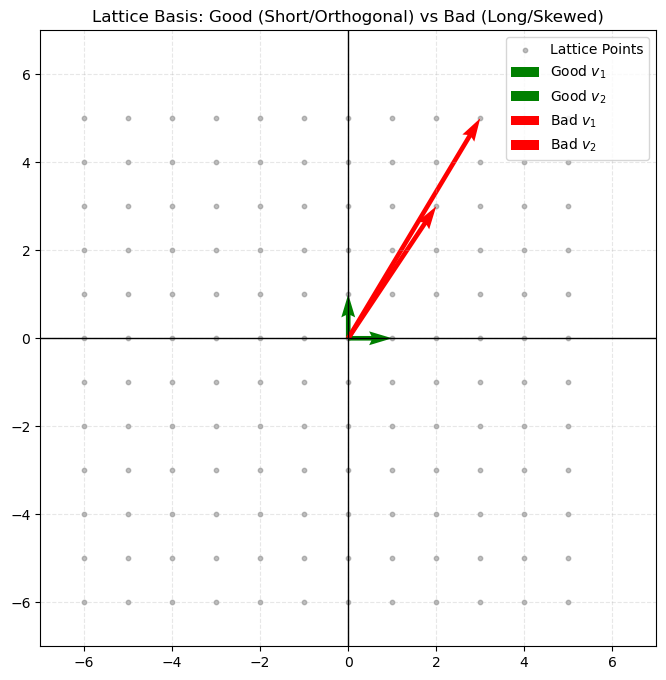

In [55]:
# 1. Define Basis Vectors
# Good basis: short and nearly orthogonal (often private key)
b_good = np.array([[1, 0], [0, 1]]) 
# Bad basis: long and highly skewed (often public key)
# Note: b_bad1 = 2*b_good1 + 3*b_good2, b_bad2 = 3*b_good1 + 5*b_good2
b_bad = np.array([[2, 3], [3, 5]])

# 2. Generate Lattice Points
N = 6
x = np.arange(-N, N)
y = np.arange(-N, N)
X, Y = np.meshgrid(x, y)
# Linear combinations of the good basis to fill the grid
pts = (X.flatten()[:, None] * b_good[0] + Y.flatten()[:, None] * b_good[1])

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pts[:, 0], pts[:, 1], c='gray', s=10, alpha=0.5, label='Lattice Points')

# Helper function to plot vectors using quiver
def plot_vec(basis, color, label_prefix):
    origin = [0, 0]
    ax.quiver(*origin, basis[0, 0], basis[0, 1], color=color, 
              angles='xy', scale_units='xy', scale=1, label=f'{label_prefix} $v_1$')
    ax.quiver(*origin, basis[1, 0], basis[1, 1], color=color, 
              angles='xy', scale_units='xy', scale=1, label=f'{label_prefix} $v_2$')

plot_vec(b_good, 'green', 'Good')
plot_vec(b_bad, 'red', 'Bad')

# Formatting
ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.set_aspect('equal')
ax.legend()
ax.set_title("Lattice Basis: Good (Short/Orthogonal) vs Bad (Long/Skewed)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## Module lattices

ML-DSA uses module based lattices and relies on the Module-LWE problem. The module lattices are chosen as they allow much faster computations and smaller key sizes compared to the standard lattices. This is because they use polynomial rings, which let the computers perform many operations at once (in parrallel).

While "ideal" lattices (used in older Ring-LWE schemes) are also fast, they have a very rigid algebraic structure that some cryptographers fear could be a "backdoor" for future attacks. Module lattices break up this structure, making them more resilient against potential mathematical exploits. They allow developers to easily adjust the security level (e.g., ML-DSA-44, 65, or 87) by simply changing the dimensions of the module matrix rather than redesigning the entire underlying ring.

A module lattice is again a grid of points, but here each point is prepresented by a set of polynomials. 
One point of the lattice can be represented as an hierarchy of three layers:
- Base level - the coefficients of the polynomials.
They are regular integers. In ML-DSA they are modulo $q = 80380417$.
- Middle level - the polynomials. The coefficients are grouped into a polynomial (of degree 255). One single polynomial represents one "dimention" in the n-dimentional level.
- Top level - the vector. One point in the module lattice is a vector (a list) of these polynomials. If the module lattice has a "rank" of 4, then one point on it is represented by a list of 4 different polynomials.

One point on the lattice is chosen to represent the secret key or (The "Good" Basis) and another one is chosen to represent the public key or The "Bad" Basis.
- **The Secret Key (The "Good" Basis):** This is a set of short, small polynomials with very small coefficients (e.g. -1, 0 or 1). Because they are small, they are easy to work with — but only the signer knows them. The signer uses the "good" basis to perform fast calculations.
- **The Public Key (The "Bad" Basis):** This is a point calculated by multiplying the public matrix $A$ by the secret point and adding an "error" $Public Key = (A \times s) + e$
When a signature is created the "Good" Basis and the "error" are used. They are secret information.
The verifier does not know them and has to use the public key (the "bad" basis) to check if the signature is "close enough" to the valid lattice points.

The number of polynomials in the secret and in the public key is defined in the variant of the ML-DSA. This is actually the dimention of the public matrix $A_{k \times l}$:

ML-DSA 87: $k = 8, l = 7$. This means public key length is $8$ and secter key length is $7$.

ML-DSA 65: $k = 6, l = 5$. This means public key length is $6$ and secter key length is $5$.

ML-DSA 44: $k = 4, l = 4$. This means public key length is $4$ and secter key length is $4$.


Below is a graphical representatation of a 2-dimetional lattice with polynomials of degree 4. This means that to define one point on the lattice we will need 2 polynomials each with 4 coefficients. In total 8 coefficients.

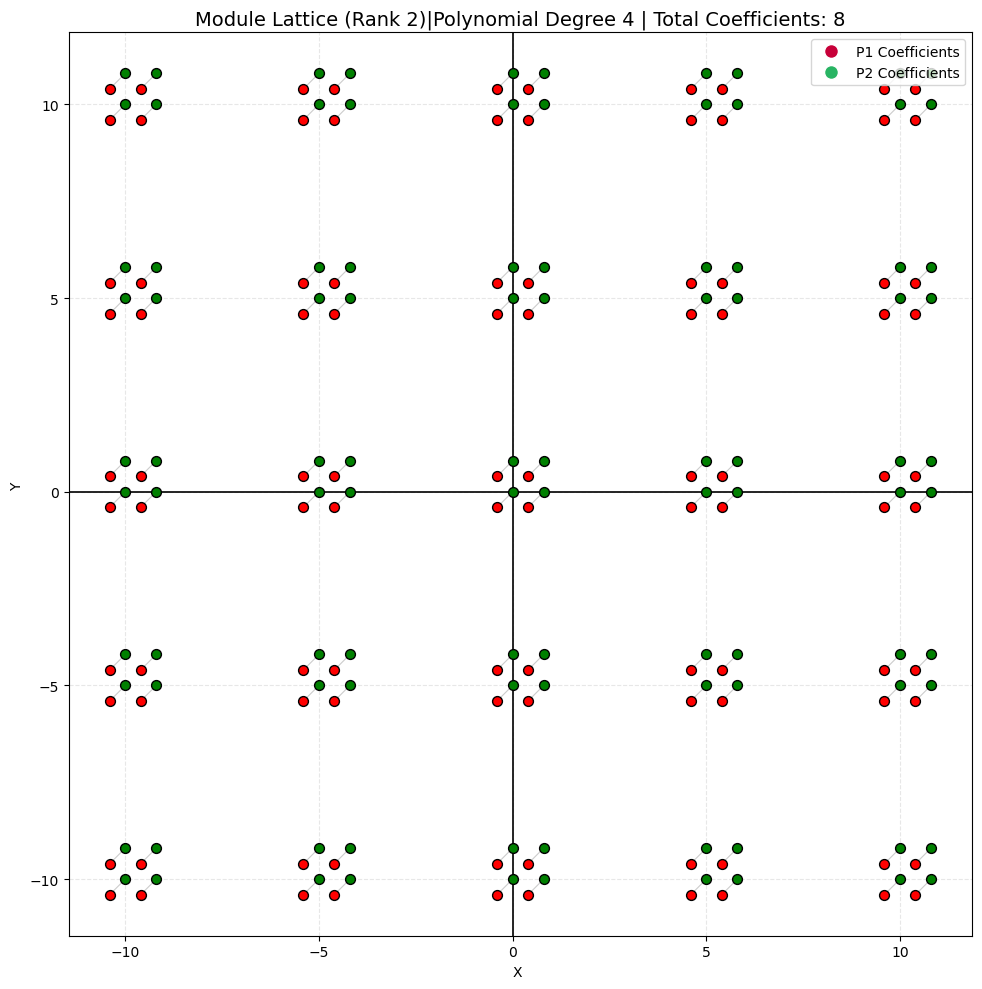

In [200]:
# 1. Module Lattice Parameters
rank = 2           # number of polynoms per each vector
poly_degree = 4    # Number of coefficients per each polynom
grid_size = 2     
spacing = 5        # Space between different vectors on the grid

# 2. Settings
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Points generation
for i in range(-grid_size, grid_size + 1):
    for j in range(-grid_size, grid_size + 1):
        # Base coordinates in 2-D space
        base_x, base_y = i * spacing, j * spacing
        
        # Parameters of the cubic projection
        side = 0.8       # Size of the cube side
        shift = 0.4      # Offset for 3-D effect
        
        # Calculate the positions of the 4 dots on low layer (Polynom 1)
        p1_coords = []
        for k in range(poly_degree):
            dx = (k % 2 - 0.5) * side
            dy = (k // 2 - 0.5) * side
            p1_coords.append((base_x + dx, base_y + dy))
            ax.scatter(base_x + dx, base_y + dy, color='red', s=50, edgecolors='black', zorder=3)
            
        # Calculate the positions of the 4 dots on Upper layer (Polynom 2)
        p2_coords = []
        for k in range(poly_degree):
            dx = (k % 2 - 0.5) * side + shift
            dy = (k // 2 - 0.5) * side + shift
            p2_coords.append((base_x + dx, base_y + dy))
            ax.scatter(base_x + dx, base_y + dy, color='green', s=50, edgecolors='black', zorder=4)
            
        # Drawing of cubic lines for cubic effect
        for k in range(4):
            ax.plot([p1_coords[k][0], p2_coords[k][0]], 
                    [p1_coords[k][1], p2_coords[k][1]], 
                    color='gray', lw=0.8, alpha=0.4, zorder=2)

# 4. Shaping the graphic
ax.set_title(f"Module Lattice (Rank {rank})|Polynomial Degree {poly_degree} | Total Coefficients: {rank * poly_degree}", fontsize=14)
ax.set_xlabel("X ")
ax.set_ylabel("Y ")

# Adding legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='P1 Coefficients', markerfacecolor='#C70039', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='P2 Coefficients', markerfacecolor='#28B463', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
plt.axhline(0, color='black', lw=1.2)
plt.axvline(0, color='black', lw=1.2)

plt.tight_layout()
plt.show()

For complete understanding below is a 3D figure showing a lattice with rank 3 and examples for good and a bad vectors.

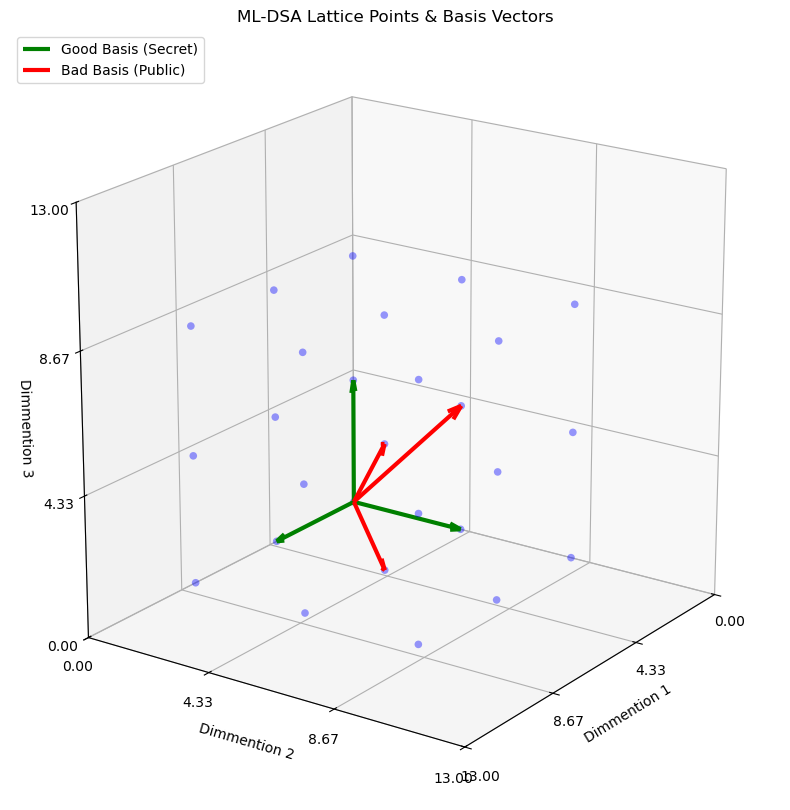

In [204]:
# 1. Setup 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Define Basis Vectors (Module rank 3)
g1, g2, g3 = np.array([4,0,0]), np.array([0,4,0]), np.array([0,0,4])
good_basis = [g1, g2, g3]

# Bad Basis: Linear combinations (Skewed)
b1, b2, b3 = g1+g2, g2+g3, g1+g2+g3 
bad_basis = [b1, b2, b3]

# 3. GENERATE AND PLOT LATTICE POINTS
# We create a 3x3x3 grid based on the Good Basis
for i in range(3):
    for j in range(3):
        for k in range(3):
            # Calculate point: p = i*v1 + j*v2 + k*v3
            p = i*g1 + j*g2 + k*g3
            # Plotting the point on the graphic
            ax.scatter(p[0], p[1], p[2], color='blue', s=30, alpha=0.4, edgecolors='none')

# 4. PLOT VECTORS (Anchored at 0,0,0)
def plot_basis(basis, color, label):
    for i, v in enumerate(basis):
        ax.quiver(0, 0, 0, v[0], v[1], v[2], 
                  color=color, linewidth=3, pivot='tail', arrow_length_ratio=0.1,
                  label=label if i == 0 else "")

plot_basis(good_basis, 'green', 'Good Basis (Secret)')
plot_basis(bad_basis, 'red', 'Bad Basis (Public)')

# 5. FIX AXES AND NUMBERING
limit = 12
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_zlim(0, limit)

# Ensure 0 is exactly at the corner
ax.set_xticks(np.linspace(0, limit + 1, 4))
ax.set_yticks(np.linspace(0, limit + 1, 4))
ax.set_zticks(np.linspace(0, limit + 1, 4))

ax.set_box_aspect([1,1,1]) # Force cubic proportions
ax.view_init(elev=20, azim=35)

ax.set_xlabel('Dimmention 1')
ax.set_ylabel('Dimmention 2')
ax.set_zlabel('Dimmention 3')
ax.set_title("ML-DSA Lattice Points & Basis Vectors")
ax.legend(loc='upper left')

plt.show()

# **5 Quantum Computing**

## Quantum Qubit (Bloch Sphere)

In quantum computing, a qubit is the basic unit of information. A qubit (short for quantum bit) is the quantum version of a classical computer bit. 

On the figure below a basic picture of a qubit can be seen.

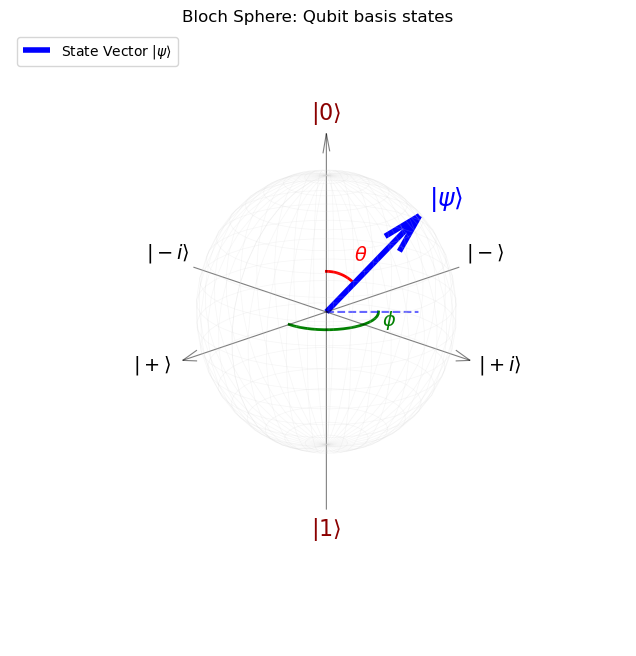

In [197]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Create the Sphere Wireframe
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
x, y, z = np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v)
ax.plot_wireframe(x, y, z, color="lightgray", linewidth=0.5, alpha=0.2)

# 2. Draw the Main Axes
ax.quiver([-1.5, 0, 0], [0, -1.5, 0], [0, 0, -1.5], 
          [3.0, 0, 0], [0, 3.0, 0], [0, 0, 2.8], 
          color='black', arrow_length_ratio=0.05, linewidth=0.8, alpha=0.5)

# 3. Basis Labels
ax.text(0, 0, 1.4, r'$|0\rangle$', fontsize=16, ha='center', color='darkred')
ax.text(0, 0, -1.7, r'$|1\rangle$', fontsize=16, ha='center', color='darkred')
ax.text(1.8, 0, 0, r'$|+\rangle$', fontsize=14, ha='center')
ax.text(-1.8, 0, 0, r'$|-\rangle$', fontsize=14, ha='center')
ax.text(0, 1.8, 0, r'$|+i\rangle$', fontsize=14, ha='center')
ax.text(0, -1.8, 0, r'$|-i\rangle$', fontsize=14, ha='center')

# 4. State Vector (Moved to the LEFT: theta=45°, phi=135°)
theta, phi = np.pi/4, 3*np.pi/4 
vx, vy, vz = np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)
ax.quiver(0, 0, 0, vx, vy, vz, color='blue', linewidth=4, pivot='tail', label=r'State Vector $|\psi\rangle$')
ax.text(vx*1.1, vy*1.1, vz*1.1, r'$|\psi\rangle$', color='blue', fontsize=18, fontweight='bold')

# 4.1 Theta Arc (Polar Angle from Z-axis)
t_arc = np.linspace(0, theta, 20)
ax.plot(0.3 * np.sin(t_arc) * np.cos(phi), 
        0.3 * np.sin(t_arc) * np.sin(phi), 
        0.3 * np.cos(t_arc), color='red', linewidth=2)
ax.text(-0.1, 0.2, 0.4, r'$\theta$', color='red', fontsize=14)

# 4.2 Phi Arc (Azimuthal Angle from X-axis)
p_arc = np.linspace(0, phi, 20)
ax.plot(0.4 * np.cos(p_arc), 0.4 * np.sin(p_arc), 0, color='green', linewidth=2)
ax.plot([0, vx], [0, vy], 0, color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
ax.text(-0.3, 0.3, -0.1, r'$\phi$', color='green', fontsize=14)

# 5. Formatting
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()
ax.view_init(elev=20, azim=45)
plt.title("Bloch Sphere: Qubit basis states")
plt.legend(loc="upper left")
plt.show()

The qubit is the fundamental building block of a quantum computer. It has the following properties:

**1. Symbols (The States):**
   While a classical bit can only be 0 or 1, a qubit can exist as 0, 1, or a combination of both simultaneously. This is called superposition. When a qubit is measured, it "collapses" from its multi-state superposition into a single classical state (either 0 or 1). Physically qubits are realized using physical systems like the spin of an electron, the polarization of a photon, or superconducting circuits.

To reprsent the quantum state of a qubit a **ket** notation is used $|\psi\rangle$. In linear algebra, a ket represents a column vector.

 - **$|0\rangle$ (North Pole):** This is the ground state, equivalent to a classical "0".

 - **$|1\rangle$ (South Pole):** This is the excited state, equivalent to a classical "1".

 - **$|+\rangle$ and $|-\rangle$ (X-axis):** These are "Superposition" states. If you measure them, you have a 50/50 chance of getting 0 or 1. They are also called the Hadamard basis.

 - **$|\psi\rangle$(The Ket):** This is the current State Vector. It represents the specific recipe of 0 and 1 that the qubit currently holds.

**2. Phase (The Timing):** If only real numbers are used we can describe only "how much" of $|0\rangle$ and $|1\rangle$ we have. By using complex numbers (which include imaginary parts), we can describe the relative "timing" or alignment between the states.

 - **$|+i\rangle$ and $|-i\rangle$ (Y-axis):** These are the imaginary superposition states or the eigenstates of the Pauli-Y operator. They are essential for algorithms that require complex phase rotations, which are the key to quantum speedups like those found in Shor's algorithm or Grover's algorithm.   

These states are defined by the following equations:
$$|+i\rangle = \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle)$$
$$|-i\rangle = \frac{1}{\sqrt{2}}(|0\rangle - i|1\rangle)$$

In both cases if the qubit is measured there is a 50% chance of getting 0 and 50% chance of getting 1. 
The binary phases are used in the Quantum Fourier Transform (QFT) to cause destructive interference on all wrong periods and constructive interference on the correct period. (Term period is used as in Shor's algoritm (the one that succsessfully breaks the RSA and ECC) the period of the function is what shall be discovered to crack the code.
 
**3. Angles (The Recipe):**

The Bloch Sphere allows us to describe any qubit state using two coordinates:

- Theta ($\theta$): This angle controls the **Probability**.

  $\circ$ If $\theta = 0$, the qubit is $|0\rangle$.

  $\circ$ If $\theta = 180^\circ (\pi)$, it is $|1\rangle$.
  
  $\circ$ If it’s at the equator ($\theta = 90^\circ$ or $\pi/2$), it is in a perfect 50/50 superposition.
  
- Phi ($\phi$): This angle represents the **Phase**.

  $\circ$ In the classical world, phase doesn't exist for a bit. In the quantum world, phase acts like the "timing" or "interference" of a wave. It doesn't change the 0-vs-1 probability, but it changes how the qubit interacts with other qubits during a calculation.



## **Usage in Quantum Computing:**

In a classical computer, bits are manipulated with gates (like AND, OR, NOT). In a quantum computer, "computing" is essentially rotating the state vector (the blue arrow ) around the sphere.

**1. Superposition:** While a classical bit can only be 0 or 1, a qubit can exist as 0, 1, or a combination of both simultaneously. By rotating the arrow from the pole to the equator, the qubit is now "both 0 and 1". This allows the computer to process a massive amount of possibilities at once.

Superposition Equation: A qubit in superposition is often written as:
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

where $\alpha$ and $\beta$ are complex numbers representing the "probability amplitudes" of the qubit being in either state.

The golden standard to create a superposition is to use the so called **Hadamard Gate** on the basis states $|0\rangle$ and $|1\rangle$. On the graphic below the $|+\rangle$ Hadamard state (the red arrow) can be seen. When a qubit is in a Hadamard state, it is neither 0 nor 1. If you measure it in the standard basis, you have a 50% chance of getting 0 and a 50% chance of getting 1.
Mathematically, this comes from squaring the amplitude: $(\frac{1}{\sqrt{2}})^2 = \frac{1}{2} = 50\%$

The Hadamard state is the starting point for almost every quantum algorithm to create a massive superpossition of all possible numbers from $0$ to $2^n - 1$ simultaneously.

Once this "cloud" of all possible answers is created, interference is used (the imaginary phases) to cancel out the wrong ones.


**2. Interference:** By adjusting the Phi ($\phi$) angle, it can be made "good" answers to amplify each other and "bad" answers to cancel each other out (like noise-canceling headphones).

Because qubits have wave-like properties (wave-particle duality), they follow the same rules as ripples in a pond:
- **Constructive Interference:** When the "peaks" of two waves line up, they reinforce each other, creating a larger wave. In a quantum computer, this amplifies the probability of measuring the correct answer.
- **Destructive Interference:** When a "peak" meets a "trough," they cancel each other out. This suppresses the probability of incorrect or "wrong" answers, essentially making them disappear before you look at the system.

**3. Measurement:** When the calculation is over, we "look" at the qubit. The arrow is forced to snap to either the North or South pole, giving a final 0 or 1 as an answer.

In quantum mechanics, any single qubit state $|\psi\rangle$ is represented as a unit vector on the Bloch Sphere. The relationship between the visual angles ($\theta$ and $\phi$) and the state is defined by the following standard equation:
$$|\psi\rangle = \cos\bigg(\frac{\theta}{2}\bigg)|0\rangle + e^{i\phi}\sin\bigg(\frac{\theta}{2}\bigg)|1\rangle $$

where:

 - $\cos\big(\frac{\theta}{2}\big)$ and $\sin\big(\frac{\theta}{2}\big)$  - are called **probability amplitudes**.
If a qubit is measured , the probability of getting $|0\rangle$ is $P(0) = \cos^2\big(\frac{\theta}{2}\big)$.
The probability of getting $|1\rangle$ is $P(1) = \sin^2\big(\frac{\theta}{2}\big)$.

Because the vector always touches the surface of the sphere, the total probability always equals 1:

$$P = P(0) + P(1) = 1$$
$$\implies P = \cos^2\bigg(\frac{\theta}{2}\bigg) + \sin^2\bigg(\frac{\theta}{2}\bigg)$$
 - $e^{i\phi}$ - the phase factor - this is the relative phase. The term represents the rotation around the Z-axis (the green arc on the graphic). It does not change the probability of measuring 0 or 1, but it is crucial for **Quantum Interference**. It determines how this qubit will add to or substract from another qubit during an algorithm.

Example:

On the graphic $\theta = \frac{\pi}{4}(45^\circ)$.

$P(0) = \cos^2\big(\frac{\theta}{2}\big) \approx 85\%$.
$P(1) = \sin^2\big(\frac{\theta}{2}\big)$.
$\implies$ The qubit is "mostly zero", but has a small quantum "tint" of one. 

Unlike classical bits, which deal with simple percentages, qubits use probability amplitudes (complex numbers). These amplitudes can be positive, negative, or even imaginary. Because they have a phase (direction), they can be rotated so that they cancel each other out.


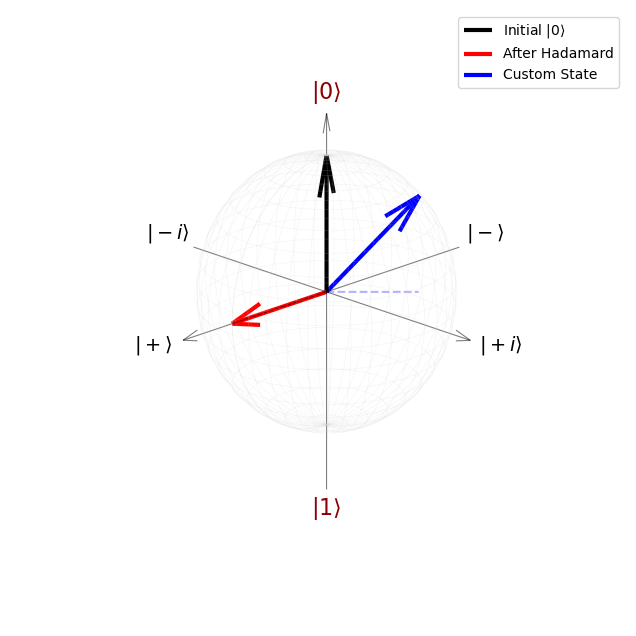

In [207]:
def get_bloch_coordinates(theta, phi):
    """Converts Bloch angles to Cartesian coordinates."""
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return x, y, z

def plot_bloch_sphere(states=None):
    """
    Plots a Bloch sphere. 
    'states' should be a list of dicts: [{'theta': 0, 'phi': 0, 'color': 'red', 'label': '0'}]
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Sphere Wireframe
    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    xs, ys, zs = np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v)
    ax.plot_wireframe(xs, ys, zs, color="lightgray", linewidth=0.5, alpha=0.2)

    # 2. Draw Axes
    ax.quiver([-1.5, 0, 0], [0, -1.5, 0], [0, 0, -1.5], 
          [3.0, 0, 0], [0, 3.0, 0], [0, 0, 2.8], 
          color='black', arrow_length_ratio=0.05, linewidth=0.8, alpha=0.5)

    # 3. Axis Labels
    ax.text(0, 0, 1.4, r'$|0\rangle$', fontsize=16, ha='center', color='darkred')
    ax.text(0, 0, -1.7, r'$|1\rangle$', fontsize=16, ha='center', color='darkred')
    ax.text(1.8, 0, 0, r'$|+\rangle$', fontsize=14, ha='center')
    ax.text(-1.8, 0, 0, r'$|-\rangle$', fontsize=14, ha='center')
    ax.text(0, 1.8, 0, r'$|+i\rangle$', fontsize=14, ha='center')
    ax.text(0, -1.8, 0, r'$|-i\rangle$', fontsize=14, ha='center')

    # 4. Plot Custom States
    if states:
        for s in states:
            vx, vy, vz = get_bloch_coordinates(s['theta'], s['phi'])
            ax.quiver(0, 0, 0, vx, vy, vz, color=s.get('color', 'blue'), 
                      linewidth=3, pivot='tail', label=s.get('label', ''))
            
            # Dashed projection to equator
            ax.plot([0, vx], [0, vy], 0, color=s.get('color', 'blue'), 
                    linestyle='--', alpha=0.3)

    # Formatting
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    ax.view_init(elev=20, azim=45)
    if states: plt.legend()
    plt.show()

# --- EXPERIMENT SECTION ---

# 1. State |0> (Initial)
initial_state = {'theta': 0, 'phi': 0, 'color': 'black', 'label': 'Initial $|0\\rangle$'}

# 2. Apply Hadamard (Move to Equator)
# Theta = pi/2 (90 degrees), Phi = 0
hadamard_state = {'theta': np.pi/2, 'phi': 0, 'color': 'red', 'label': 'After Hadamard'}

# 3. Custom state
custom_state = {'theta': np.pi/4, 'phi': 3*np.pi/4, 'color': 'blue', 'label': 'Custom State'}

# Plot them all together!
plot_bloch_sphere([initial_state, hadamard_state, custom_state])

## Shor's algorithm

A quantum algorithm is essentially a "carefully choreographed sequence of interference events" designed to steer the system toward a 100% chance of the right outcome.

**The Shor's algorithm** for example uses the Quantum Fourier Transform (QFT) to create a massive interference pattern that reveals the "period" or frequency of a number. In other words, a large matrices with complex numbers are used to create rotations. These rotations ensure that millions of "wrong" mathematical paths cancel to zero, leaving only the period $r$ (the secret to the prime factors) with a high probability.

**How this threatens modern cryptography?**
As it was already mentioned, the classical crypto algorithms rely on mathematical problems that are easy to do in one direction but extremely hard to reverse.
- **RSA** relies on the difficulty of **Factoring**: Taking a giant number $N$ and finding the two prime numbers ($p$ and $q$) that multiply to create it.
- **ECC** relies on the **Discrete Logarithm Problem**: Finding how many times a point was added to itself on a curve.
  
Mathematically, both problems can be converted into a **Period Finding problem**. 

Imagine a function $f(x) = a^x\ (mod\ N)$. This function is periodic—it repeats its values every $r$ steps. If that period $r$ can be found, algorithm is broken.

The classical computers fail, because to find the period $r$ $f(x)$ for x = 1,2,3... has to be calculated unitl a pattern is repeated. For a 2048-bit RSA key, the period is so massive that a classical computer would take bilions of years to find it. It has to check one value at a time.

Shor’s Algorithm doesn't check values one by one. It uses the Qubits to see the entire pattern at once.
1. **Superposition** - The algorithm puts a register of qubits into a superposition of all possible values of $x$.
2. **Quantum Parallelism** - It calculates $f(x) = a^x\ (mod\ N)$ for all those values simultaneously. This creates a state where the "answers" are all tangled together.
3. **The Quantum Fourier Transform (QFT)** - The QFT causes destructive interference on all the wrong periods and constructive interference on the correct period $r$.
4. **Measurement** - When qubits are measured, the wave function collapses. Because of the interference, the probability is "peaked" at the correct period $r$.



**Example:** Period Finding for $7^x\ (mod\ 15)$

Finding the period of $7^x\ (mod\ 15)$. The classical approach $7^1 = 7, 7^2 = 4, 7^3 = 13, 7^4 = 1$. The period $r=4$.

In [221]:
# --- REGULAR (CLASSICAL) APPROACH ---
N, a = 15, 7
x_vals = np.arange(12)
y_vals = [(a**int(x)) % N for x in x_vals]

# --- QISKIT (QUANTUM) APPROACH ---
# Simplification for N=15, a=7 using 3 counting qubits
qc = QuantumCircuit(7, 3) 
qc.h([0, 1, 2]) # Superposition
qc.x(6)         # Target register to |1>

# (Simplified) modular exponentiation gates for 7^x mod 15
# In a real setup, these are 'controlled' gates
qc.cx(0, 4); qc.cx(0, 5) # simplified mapping
qc.cx(1, 3); qc.cx(1, 5)
qc.append(QFTGate(3).inverse(), [0, 1, 2])
qc.measure([0, 1, 2], [0, 1, 2])

# Run Simulation
backend = AerSimulator()
t_qc = transpile(qc, backend)
counts = backend.run(t_qc).result().get_counts()

print(f"Quantum Measurement (Counts): {counts}")

Quantum Measurement (Counts): {'110': 247, '010': 262, '000': 253, '100': 262}


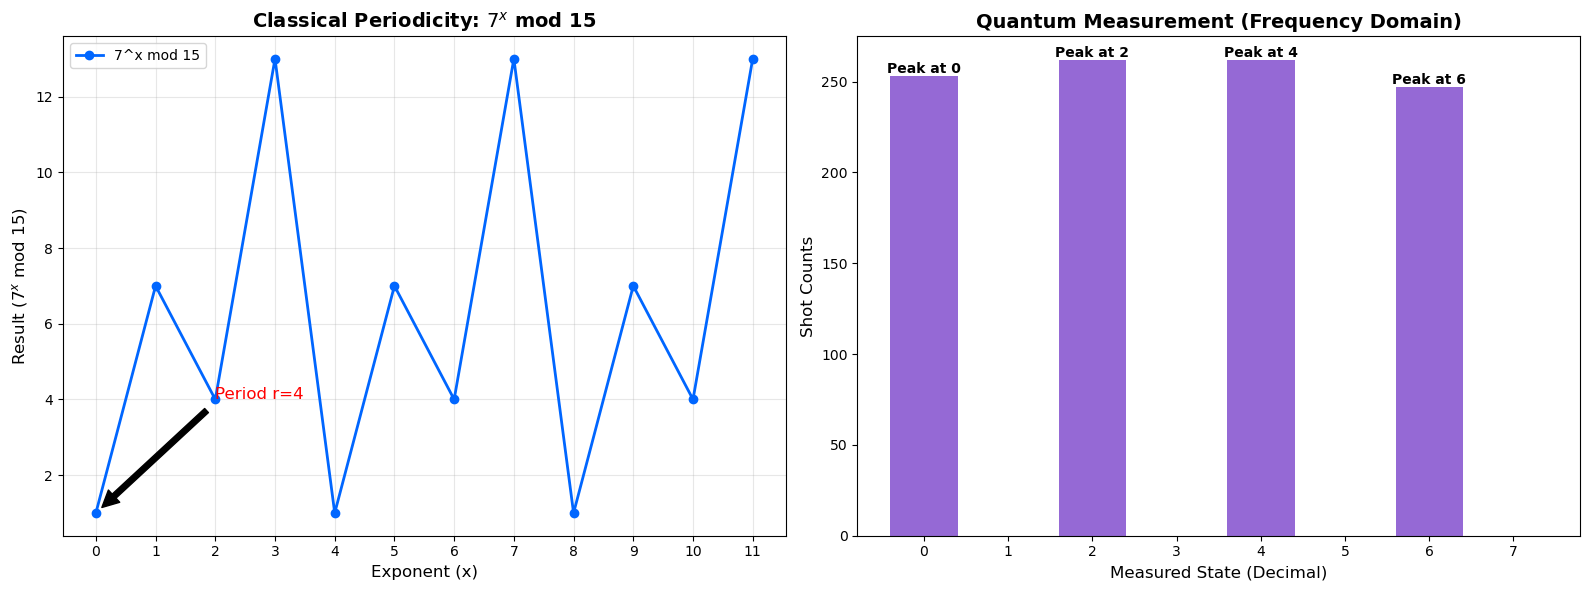

In [233]:
# Prepare Quantum Data from 'counts' result
# This converts the bitstring keys (e.g., '010') to integers (e.g., 2)
all_states = [format(i, '03b') for i in range(8)]
plot_counts = [counts.get(s, 0) for s in all_states]
decimal_states = np.arange(8)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: The Classical Periodic Function
ax1.plot(x_vals, y_vals, color='#0066ff', marker='o', linestyle='-', linewidth=2, label=f'7^x mod 15') # label
ax1.set_title(f"Classical Periodicity: $7^x$ mod 15", fontsize=14, fontweight='bold')
ax1.set_xlabel("Exponent (x)", fontsize=12)
ax1.set_ylabel("Result ($7^x$ mod 15)", fontsize=12)
ax1.set_xticks(x_vals)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Highlight the period r=4
ax1.annotate('Period r=4', xy=(0, 1), xytext=(2, 4),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, color='red')

# Right Plot: The Quantum Measurement Peaks
bars = ax2.bar(decimal_states, plot_counts, color='#6929c4', alpha=0.7)
ax2.set_title("Quantum Measurement (Frequency Domain)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Measured State (Decimal)", fontsize=12)
ax2.set_ylabel("Shot Counts", fontsize=12)
ax2.set_xticks(decimal_states)

# Label the peaks
for i, rect in enumerate(bars):
    height = rect.get_height()
    if height > max(plot_counts)*0.1: # Only label significant peaks
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                f'Peak at {i}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

The Left Graph (classical apptoach) shows the raw periodic function. The value 1 repeats every 4 steps, i.e. period $r$ = 4.

The Right Graph (quantum approach) shows the result of the Inverse QFT. The QFT acts like a Fourier Transform; it converts the periodic signal into frequency peaks.

# Types of attacks

## Chosen Message Attack (CMA)

The attacker chooses the input to be processed by the secret key. 
The goal for a signature scheme is forgery rather than decryption.

ML-DSA is designed to be mathematically resistant to these attacks. Its primary security goal is **Strong Existential Unforgeability under Chosen Message Attack (SUF-CMA)**.
This means that an attacker cannot forge a new signature for a message that has already been signed.

Example:

Message: "Pay 100 euro" is signed with valid signature.

Attacker could modify the original message to "Pay 200 euro" and slightly modify the signature bits so they look different but still verify as valid for the tampered message "Pay 200 euro".

In an SUF-CMA this slight modification is impossible. Every single bit of signature is effectively locked.

In ML-DSA, rejection sampling is the mechanism that ensures a signature is both secure and unique (SUF-CMA). It acts as a "quality control" step that discards any signature that might leak the secret key or allow someone to create an alternative version.


# References

1. National Institute of Standards and Technology (2024) Module-Lattice-Based Digital Signature Standard. (Department of Commerce, Washington, D.C.), Federal Information Processing Standards Publication (FIPS) NIST FIPS 204. https://doi.org/10.6028/NIST.FIPS.204
2. https://sites.millersville.edu/bikenaga/abstract-algebra-1/quotient-rings-of-polynomial-rings/quotient-rings-of-polynomial-rings.html
3. https://github.com/GiacomoPope/dilithium-py
4. https://words.filippo.io/kyber-math/
5. https://sites.calvin.edu/scofield/courses/m256/materials/eigenstuff.pdf
6. https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/shor.ipynb
7. https://quantum.cloud.ibm.com/learning/en/modules/computer-science/shors-algorithm
8. https://www.youtube.com/@chalktalkmath